In [15]:
using LinearAlgebra
using FFTW
using Plots
using DelimitedFiles

In [16]:
LDOS_minus = readdlm("LDOS_d+id_minus_julia_code_strontium_ruthenate_BdG.csv", Char(44));
LDOS_plus = readdlm("LDOS_d+id_plus_julia_code_strontium_ruthenate_BdG.csv", Char(44));

LDOS = LDOS_minus + LDOS_plus; ## add the two bands
LDOS_full = copy(LDOS);


In [17]:
# Region of interest for plotting
const ROI_X = 159:241
const ROI_Y = 159:241
const HALO = 3  # because shifts are -3:3

# Validate ROI against loaded LDOS size
nx, ny = size(LDOS)
@assert first(ROI_X)-HALO >= 1 && last(ROI_X)+HALO <= nx "ROI_X with halo is out of LDOS bounds"
@assert first(ROI_Y)-HALO >= 1 && last(ROI_Y)+HALO <= ny "ROI_Y with halo is out of LDOS bounds"

# Source LDOS block needed to compute ROI (ROI + halo)
const SRC_X = (first(ROI_X)-HALO):(last(ROI_X)+HALO)
const SRC_Y = (first(ROI_Y)-HALO):(last(ROI_Y)+HALO)

# Keep only necessary LDOS chunk
LDOS = @view LDOS[SRC_X, SRC_Y]

# Fine grid only over ROI
NFineX = 10 * length(ROI_X)
NFineY = 10 * length(ROI_Y)
x_fine_grid = range(first(ROI_X), last(ROI_X), length=NFineX)
y_fine_grid = range(first(ROI_Y), last(ROI_Y), length=NFineY)

# Global LDOS indices -> local view indices
gx2lx(gx) = gx - first(SRC_X) + 1
gy2ly(gy) = gy - first(SRC_Y) + 1


gy2ly (generic function with 1 method)

In [18]:
using QuadGK

In [19]:
a=1;

In [20]:
## Define a Wannier function within one unit cell
function Wannier_xy_square(x,y)
    sigma_Wannier = 0.8*a;
    return ((x^2 + y^2)/a^2)*exp(-(x^2 + y^2)/(2*sigma_Wannier^2))^2
end

##Normalize Wannier function so that it integrates to 1 over the unit cell
integral = quadgk(x -> quadgk(y -> Wannier_xy_square(x,y), -10*a/2, 10*a/2)[1], -10*a/2, 10*a/2)[1]
println("Integral of Wannier function over unit cell: ", integral)

Integral of Wannier function over unit cell: 1.2867963509103797


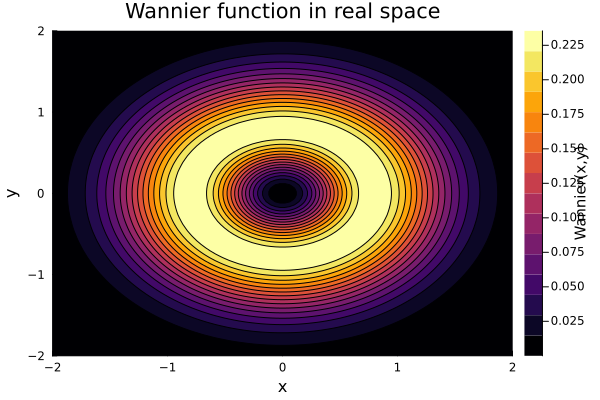

In [21]:
## Make a plot of the Wannier function
x_grid = range(-2*a, 2*a, length=100)
y_grid = range(-2*a, 2*a, length=100)
Wannier_values = [Wannier_xy_square(x,y) for x in x_grid, y in y_grid]
p_Wann = contourf(x_grid, y_grid, Wannier_values', title="Wannier function in real space", xlabel="x", ylabel="y", colorbar_title="Wannier(x,y)")


In [22]:
# Direct (simple) convolution-style Wannier accumulation
Wannier_times_LDOS = zeros(Float64, NFineX, NFineY)
normW = 1 / integral

for ii in 1:NFineX
    x = x_fine_grid[ii]
    x0 = floor(Int, x)
    for jj in 1:NFineY
        y = y_fine_grid[jj]
        y0 = floor(Int, y)

        acc = 0.0
        for sx in -HALO:HALO
            gx = x0 + sx
            lx = gx2lx(gx)
            for sy in -HALO:HALO
                gy = y0 + sy
                ly = gy2ly(gy)
                acc += normW * Wannier_xy_square(x - gx, y - gy) * LDOS[lx, ly]
            end
        end

        Wannier_times_LDOS[ii, jj] = acc
    end
end

In [23]:
minimum([maximum(Wannier_times_LDOS), abs(minimum(Wannier_times_LDOS))])

0.0024203601221570972

In [24]:
## export only inside plotting limits
csv_path = joinpath(pwd(), "d+id_Wannier_times_LDOS_export.csv")

x_min, x_max = ROI_X[1], ROI_X[end]
y_min, y_max = ROI_Y[1], ROI_Y[end]

open(csv_path, "w") do io
    # println(io, "ii_value,jj_value,Wannier_times_LDOS")
    for ii in axes(Wannier_times_LDOS, 1)
        x = x_fine_grid[ii]
        if x_min <= x <= x_max
            for jj in axes(Wannier_times_LDOS, 2)
                y = y_fine_grid[jj]
                if y_min <= y <= y_max
                    println(io, "$(ii),$(jj),$(Wannier_times_LDOS[ii, jj])")
                end
            end
        end
    end
end

println("Exported CSV: ", csv_path)

Exported CSV: /home/archisman/Documents/GitHub/tunneling_conductance_tomography/strontium_ruthenate/fig 3 codes/fig 3b single impurity/d+id_Wannier_times_LDOS_export.csv


In [25]:
theta = pi/6;

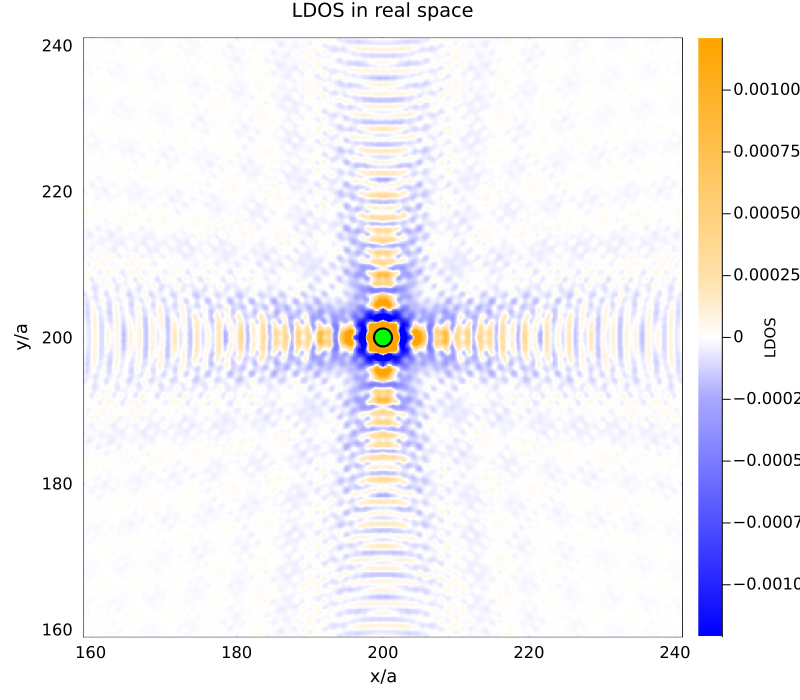

In [26]:
clim = minimum([maximum(Wannier_times_LDOS), abs(minimum(Wannier_times_LDOS))])/2
custom_cmap_symmetric = cgrad([:blue, :white, :orange], [0.4, 0.6])
p = heatmap(x_fine_grid, y_fine_grid, Wannier_times_LDOS', 
    xlabel="x/a", ylabel="y/a", 
    title="LDOS in real space",
    colorbar_title="LDOS", 
    c=custom_cmap_symmetric, 
    aspect_ratio=1, 
    clim=(-clim, clim),
    framestyle=:box,
    legend=false,
    size=(800, 700),
    margin=2Plots.mm,
    tickfontsize=11,
    guidefontsize=12,
    titlefontsize=13,
    colorbar=:right,
    xlims=(ROI_X[1], ROI_X[end]),
    ylims=(ROI_Y[1], ROI_Y[end])
)

scatter!(p, [200], [200],
    markersize=10,
    markercolor=:lime,
    markerstrokecolor=:black,
    markerstrokewidth=1.5,
    label=false
)

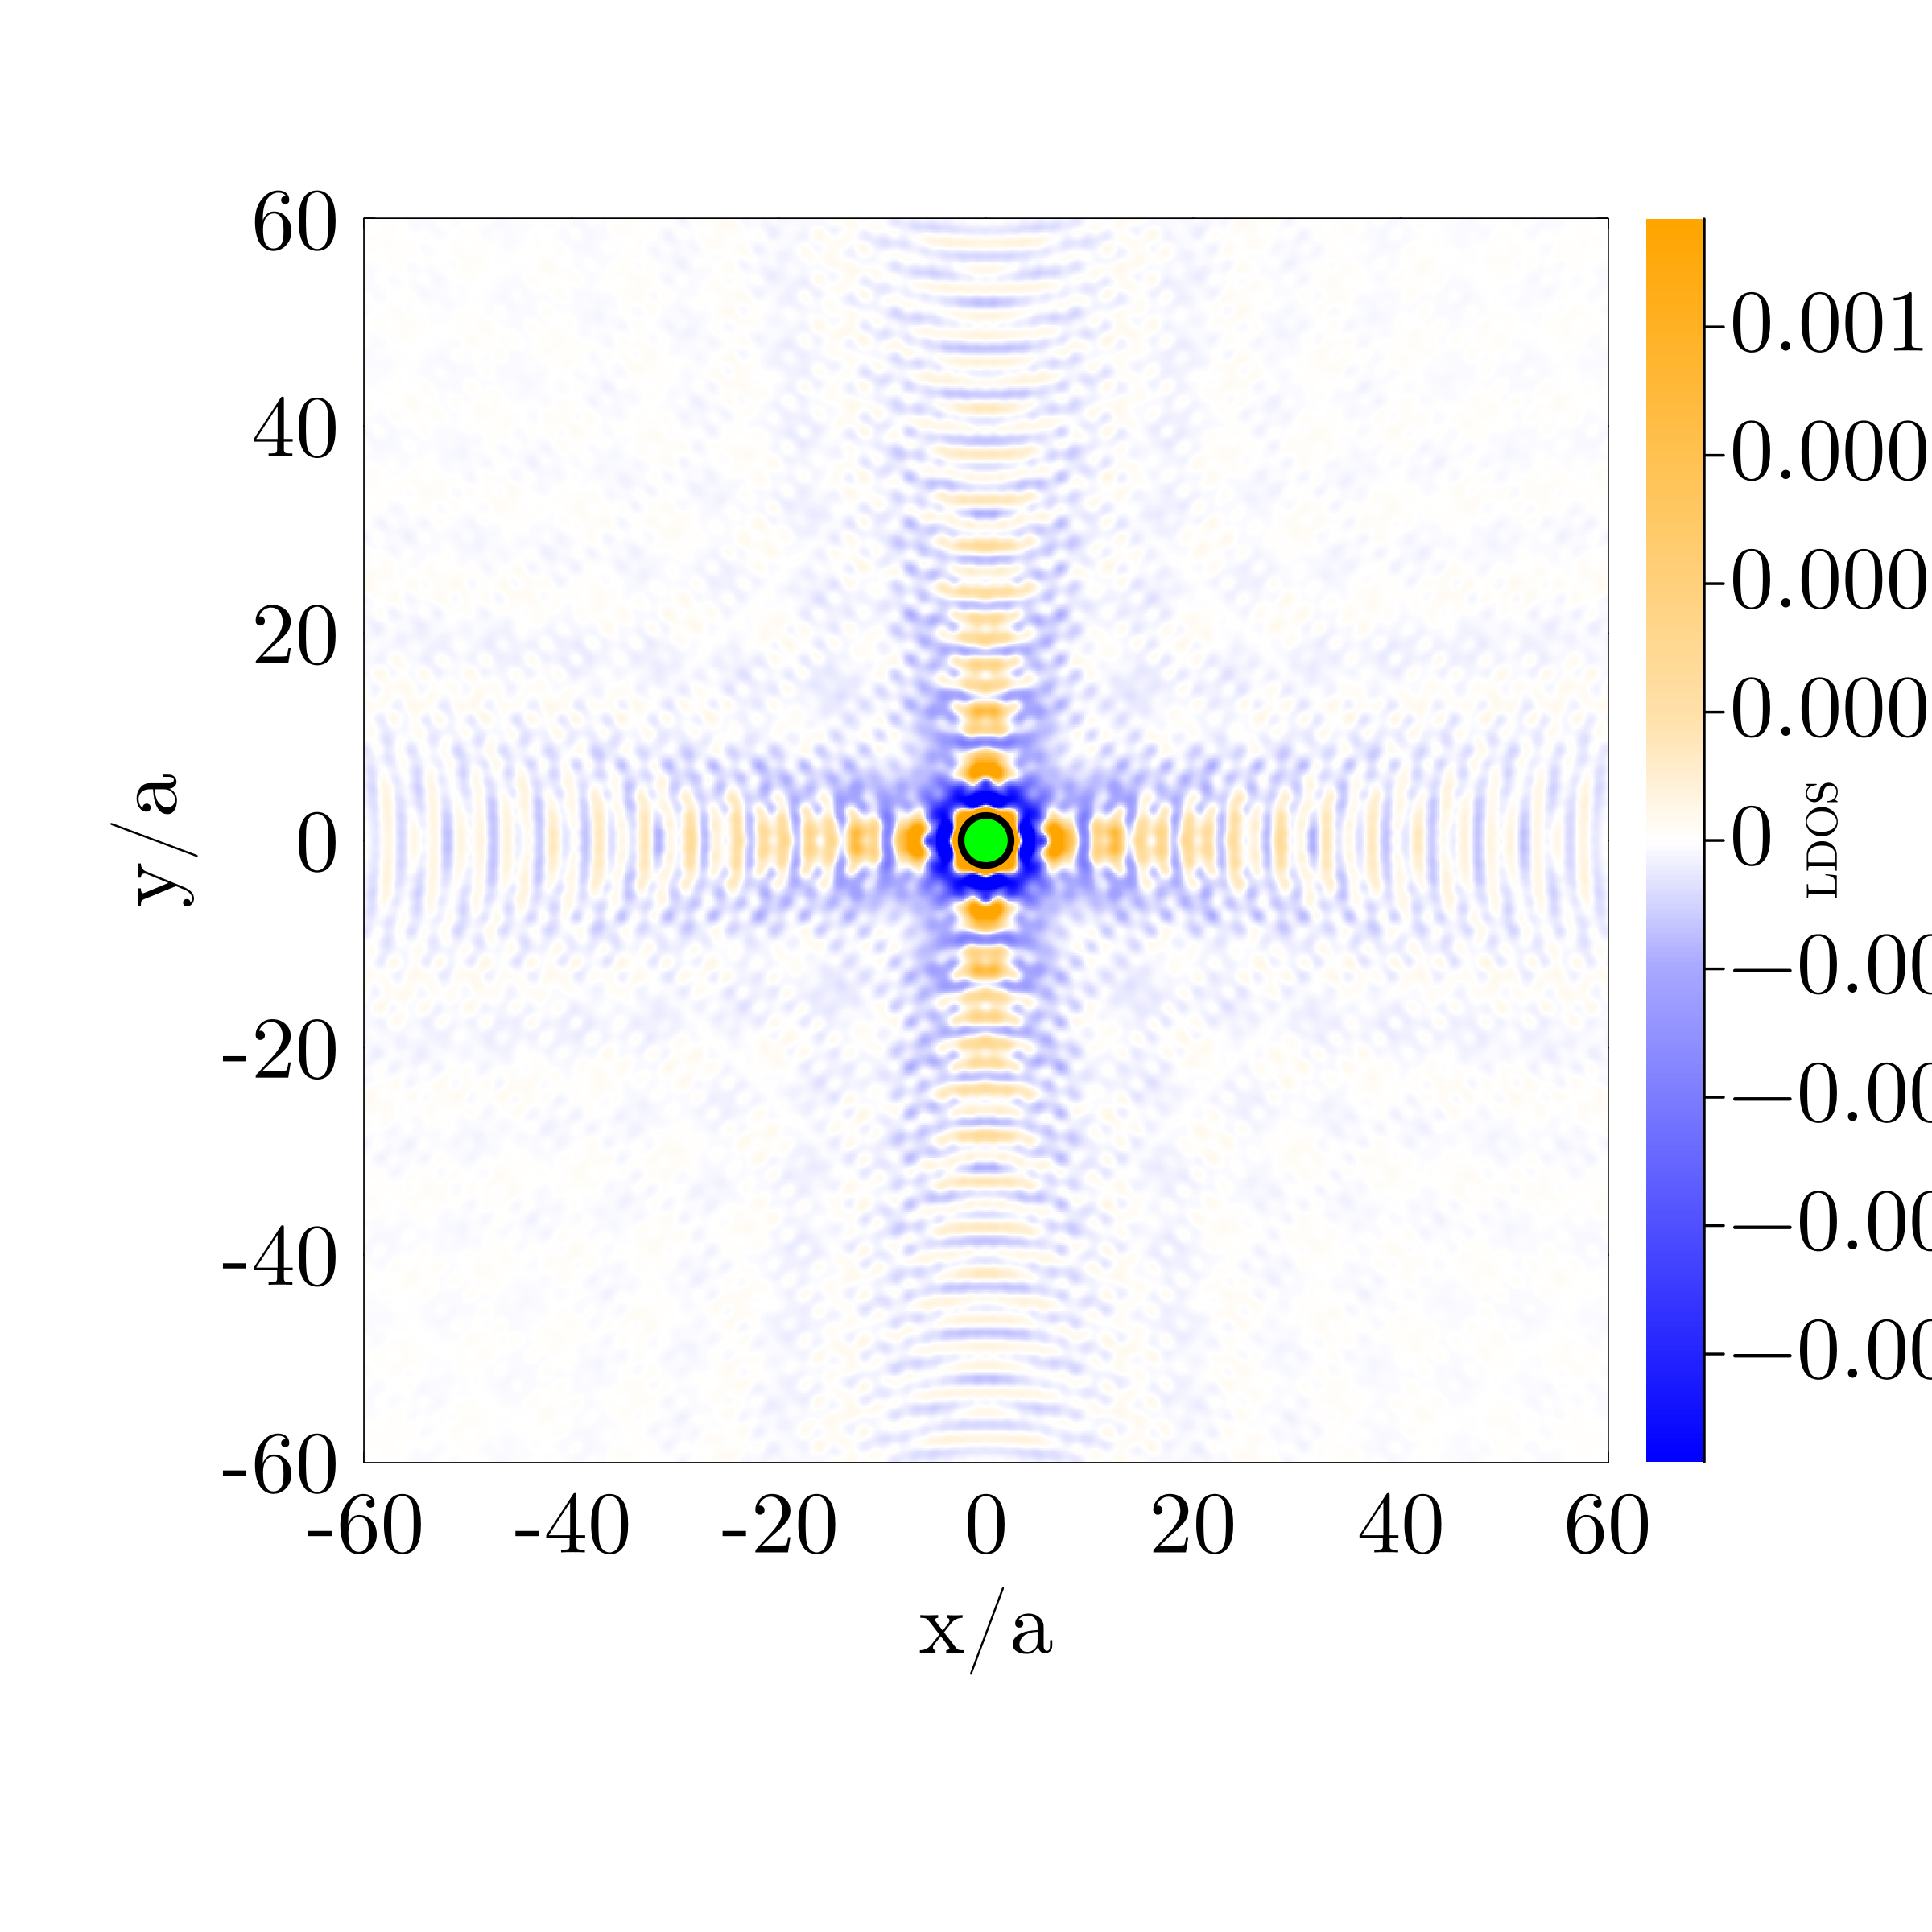

In [27]:
clim = minimum([maximum(Wannier_times_LDOS), abs(minimum(Wannier_times_LDOS))])/2
custom_cmap_symmetric = cgrad([:blue, :white, :orange], [0.4, 0.6])
# Re-label physical coordinates to centered axes for publication plots
tick_values = -60:20:60
xtick_positions = range(first(ROI_X), last(ROI_X), length=length(tick_values))
ytick_positions = range(first(ROI_Y), last(ROI_Y), length=length(tick_values))
tick_labels = string.(collect(tick_values))
p1 = heatmap(x_fine_grid, y_fine_grid, Wannier_times_LDOS', 
    xlabel="x/a", ylabel="y/a", 
    # title=("clim=",clim),
    colorbar_title="LDOS", 
    c=custom_cmap_symmetric,
    aspect_ratio=1, 
    clim=(-clim, clim),
    framestyle=:box,
    legend=false,
    size=(800, 800),
    dpi=300,
    margin=6Plots.mm,
    tickfontsize=20,
    guidefontsize=20,
    titlefontsize=16,
    fontfamily="Computer Modern",
    thickness_scaling=1.15,
    colorbar=:right,
    xticks=(xtick_positions, tick_labels),
    yticks=(ytick_positions, tick_labels),
    xlims=(ROI_X[1], ROI_X[end]),
    ylims=(ROI_Y[1], ROI_Y[end])
)


scatter!(p1, [200], [200],
    markersize=10,
    markercolor=:lime,
    markerstrokecolor=:black,
    markerstrokewidth=1.5,
    label=false
)

p1

In [28]:
### Export the plot p to pdf
savefig(p1, "d+id_Wannier_times_LDOS_plot.pdf")

"/home/archisman/Documents/GitHub/tunneling_conductance_tomography/strontium_ruthenate/fig 3 codes/fig 3b single impurity/d+id_Wannier_times_LDOS_plot.pdf"